#           Projet : Développement d'une Application de Bureau pour la Météo


## Introduction:

Ce projet est le fruit d'un travail en suivant les étapes données dans l'énoncé d'un TP, visant à développer progressivement une application complète de prévisions météorologiques. Le processus s'est déroulé en trois étapes principales, donnant naissance à trois modèles distincts de codes :

**Premier modèle** : Un code dédié à récupérer les données météorologiques via des API publiques (Open-Meteo et Geocode) et à les sauvegarder dans un fichier JSON pour une utilisation ultérieure.

**Deuxième modèle** : Un code amélioré introduisant une interface utilisateur simple avec la bibliothèque tkinter, permettant d'afficher les prévisions de manière basique.

**Troisième modèle** : Une version finale intégrant customtkinter pour une interface moderne et ergonomique, avec des fonctionnalités avancées comme la visualisation graphique des prévisions via matplotlib, ainsi que la sauvegarde et le chargement des données météo.

#### troisieme modèle : (Version finale de projet)

In [2]:
pip install customtkinter  


Note: you may need to restart the kernel to use updated packages.


In [5]:
import requests
import json
import customtkinter as ctk
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Variable globale pour le graphique
canvas = None

# Fonction pour récupérer les données météo
def obtenir_meteo():
    global canvas  # Permet de modifier la variable globale (supprime si un grqph existe deja)
    
    ville = entree_ville.get()  # Récupérer le nom de la ville depuis l'entrée utilisateur
    if not ville: 
        message_texte.configure(text="Erreur : Veuillez saisir une ville ", text_color="red")
        return

    # Utiliser l'API geocode pour obtenir latitude et longitude
    geo_url = f"https://geocode.maps.co/search?q={ville}"
    response1 = requests.get(geo_url)

    # Initialiser les variables latitude et longitude
    latitude = None
    longitude = None

    if response1.status_code == 200:     # Vérifier si la requête à l'API a réussi
        geo_data = response1.json()  # liste de dictionnaires contenant des informations sur les lieux possibles
        if len(geo_data) > 0: #vérifier si la liste est n'est pas vide (cad n a aucune info sur la ville )
            latitude = geo_data[0].get('lat') #récupérer la valeur associée à la clé 'lat' ,(geo_data[0]) premier résultat  retourné par l'API
            longitude = geo_data[0].get('lon')
        else:
            message_texte.configure(text="Erreur : Ville introuvable. Vérifiez le nom et réessayez.", text_color="red")
            return
    else:
        message_texte.configure(text="Erreur : Impossible de se connecter à l'API des coordonnées.", text_color="red")
        return

    # Vérifier que les coordonnées ont bien été obtenues
    if latitude is None or longitude is None:
        message_texte.configure(text="Erreur : Les coordonnées de la ville n'ont pas été trouvées.", text_color="red")
        return   #Stoppe l'exécution de la fonction à ce stade

    # API Open-Meteo
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Africa/Casablanca"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json() #liste de dictionnaire

        # Extraire les données météo
        current_weather = {
            "temperature": data['current_weather']['temperature'],
            "windspeed": data['current_weather']['windspeed'],
        }

        daily_forecast = {
            "dates": data['daily']['time'],
            "max_temps": data['daily']['temperature_2m_max'],
            "min_temps": data['daily']['temperature_2m_min']
        }
        donnes = { 
        "daily_forecast": daily_forecast,
        "current_weather": current_weather
        }
        # Afficher la météo actuelle
        label_meteo.configure(
            text=f"Météo actuelle à {ville} :\nTempérature : {current_weather['temperature']}°C\n"
                 f"Vitesse du vent : {current_weather['windspeed']} km/h"
        ) #mis à jour pour afficher des informations dynamiques en fonction des données récupérées
        # Supprimer l'ancien graphique s'il existe
        if canvas is not None:
            canvas.get_tk_widget().destroy()
       

        # Afficher les prévisions météo sur un graphique
        dates = daily_forecast["dates"]
        max_temps = daily_forecast["max_temps"]
        min_temps = daily_forecast["min_temps"]

        figure = Figure(figsize=(8, 6)) #Crée une figure de taille (8, 6) pouces 
        plot = figure.add_subplot(1, 1, 1) #ajoute un graph a cette figure
        plot.plot(dates, max_temps, label="Température maximale", marker='o' )
        plot.plot(dates, min_temps, label="Température minimale", marker='s' )
        plot.set_title(f"Prévisions des températures à {ville}")
        plot.set_xlabel("Dates")
        plot.set_ylabel("Température (°C)")
        plot.legend() 
        plot.grid()

        # Afficher le graphique dans l'interface
        canvas = FigureCanvasTkAgg(figure, master=fenetre) #le graphique doit être intégré dans la fenêtre principale 
        canvas.get_tk_widget().pack()#Convertit le graphique Matplotlib en un widget compatible Tkinter et l'ajoute à la fenêtre
        canvas.draw()
        # Sauvegarder les données dans un fichier JSON
        sauvegarder_donnees("open_meteo.json", donnes)
        message_texte.configure(text=f"Les données de {ville} ont été sauvegardées avec succès !", text_color="green")
    else:
        message_texte.configure(text="Erreur : Impossible de récupérer les données météo.", text_color="red")




# Fonction pour sauvegarder les données dans un fichier JSON
def sauvegarder_donnees(nom_fichier, contenu):
    with open(nom_fichier, 'w') as fichier:
        json.dump(contenu, fichier, indent=2)

# Fonction pour charger les données depuis un fichier JSON
def charger_donnees():
    try:
        with open("open_meteo.json", 'r') as fichier:
            contenu = json.load(fichier)
        message_texte.configure(text=f"Données chargées :\n{json.dumps(contenu, indent=2)}", text_color="blue")
    except FileNotFoundError:
        message_texte.configure(text="Erreur : Le fichier 'open_meteo.json' n'existe pas.", text_color="red")
        

# Initialiser la fenêtre principale avec customtkinter
ctk.set_appearance_mode("dark")  # Thème sombre
ctk.set_default_color_theme("blue")  # Couleur de thème

fenetre = ctk.CTk()
fenetre.title("Météo MAROC")
fenetre.geometry("700x700")

# Champ de saisie pour entrer le nom de la ville
label_ville = ctk.CTkLabel(fenetre, text="Entrez le nom de la ville :", font=("Arial", 14)) #affiche toujours le même texte
label_ville.pack(pady=10)

entree_ville = ctk.CTkEntry(fenetre, width=300, font=("Arial", 12)) # la valeur entrer dans cette label va etre recuperrer par l intruction ene haut (entrer_label.get)
entree_ville.pack(pady=10)

# Bouton pour récupérer les données météo
bouton_meteo = ctk.CTkButton(fenetre, text="Afficher les prévisions", command=obtenir_meteo, font=("Arial", 12)) # fait appel à la fonction
bouton_meteo.pack(pady=10)

# Label pour afficher la météo actuelle
label_meteo = ctk.CTkLabel(fenetre, text="", font=("Arial", 12), justify="left") # le texte est dynamiaue va etre recupperer d'apres (label_meteo.configure)
label_meteo.pack(pady=10)

# Label pour afficher les erreurs ou succès
message_texte = ctk.CTkLabel(fenetre, text="", font=("Arial", 10), width=400, justify="center")
message_texte.pack(pady=10)

# Boutons pour sauvegarder et charger les données
bouton_sauvegarder = ctk.CTkButton(fenetre, text="Sauvegarder les données", command=sauvegarder_donnees("open_meteo.json",  "donnes"), font=("Arial", 12))
bouton_sauvegarder.pack(pady=10)

bouton_charger = ctk.CTkButton(fenetre, text="Charger les données", command=charger_donnees, font=("Arial", 12))
bouton_charger.pack(pady=10)


# Lancement boucle principale
fenetre.mainloop()


#### Premier modèle 

Entrez le nom de la ville :  agadir


Coordonnées de agadir : Latitude 30.4205162, Longitude -9.5838532
Données sauvegardées dans le fichier : open_meteo.json
Données chargées depuis le fichier : open_meteo.json
Données chargées : {
  "daily_forecast": {
    "dates": [
      "2024-11-25",
      "2024-11-26",
      "2024-11-27",
      "2024-11-28",
      "2024-11-29",
      "2024-11-30",
      "2024-12-01"
    ],
    "max_temps": [
      32.6,
      30.4,
      31.7,
      32.2,
      28.7,
      28.7,
      26.3
    ],
    "min_temps": [
      22.7,
      20.9,
      19.7,
      20.2,
      18.5,
      17.9,
      18.3
    ],
    "precipitation_sum": [
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0
    ]
  },
  "current_weather": {
    "temperature": 23.0,
    "windspeed": 7.0
  }
}

Météo actuelle à Agadir :
Température : 23.0°C
Vitesse du vent : 7.0 km/h

Prévisions journalières :
2024-11-25 - Max : 32.6°C, Min : 22.7°C, Précipitations : 0.0 mm
2024-11-26 - Max : 30.4°C, Min : 20.9°C, Précipi

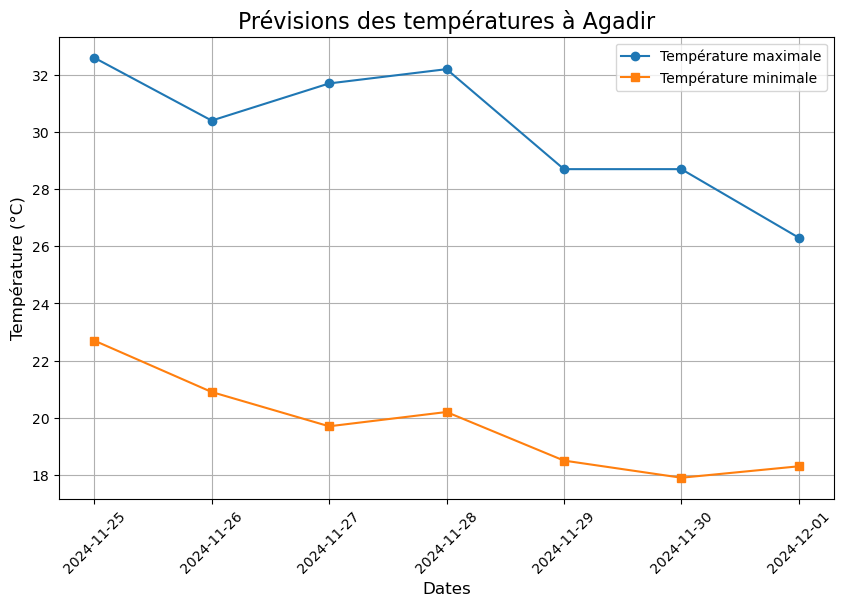

In [6]:
import requests
import json
import matplotlib.pyplot as plt

# Demander à l'utilisateur d'entrer le nom de la ville
ville = input("Entrez le nom de la ville : ")

# Utiliser une API geocode pour obtenir latitude et longitude de ville choisis
geo_url = f"https://geocode.maps.co/search?q={ville}"

# Faire la requête pour récupérer les coordonnées
response1 = requests.get(geo_url)

# Initialiser les variables latitude et longitude
latitude = None
longitude = None

if response1.status_code == 200:  # Vérifier si la requête à l'API a réussi
    geo_data = response1.json() # liste de dictionnaires contenant des informations sur les lieux possibles
    if len(geo_data) > 0:  # Vérifier si la liste est n'est pas vide (cad n a aucune info sur la ville )
        # Vérifier si 'lat' et 'lon' sont disponibles
        latitude = geo_data[0].get('lat')  # .get('lat') est utilisée pour récupérer la valeur associée à la clé 'lat' ,(geo_data[0]) premier résultat  retourné par l'API.
        longitude = geo_data[0].get('lon')  # Longitude
        print(f"Coordonnées de {ville} : Latitude {latitude}, Longitude {longitude}")
    else:
        print("Erreur : La ville n'a pas été trouvée. Vérifiez le nom et réessayez.")
        exit()
else:
    print("Erreur : Impossible de se connecter à l'API pour récupérer les coordonnées.")
    exit()



# Construire l'URL de l'API Open-Meteo avec les coordonnées obtenues
url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Africa/Casablanca"

# Faire la requête à l'API météo
response = requests.get(url)

if response.status_code == 200:  # Vérifier si la requête météo a réussi
    # Convertir les données en JSON
    data = response.json()
    
    # Extraire les données météo actuelles et les prévisions
    current_weather = {
        "temperature": data['current_weather']['temperature'],
        "windspeed": data['current_weather']['windspeed'],
    }

    daily_forecast = {
        "dates": data['daily']['time'],
        "max_temps": data['daily']['temperature_2m_max'],
        "min_temps": data['daily']['temperature_2m_min'],
        "precipitation_sum": data['daily']['precipitation_sum']
    }
    donnes = { 
        "daily_forecast": daily_forecast,
        "current_weather": current_weather
    }

    # Fonction pour sauvegarder les données dans un fichier JSON
    def sauvegarder_donnees(nom_fichier, contenu):
        with open(nom_fichier, 'w') as fichier:
            json.dump(contenu, fichier, indent=2)          # Sauvegarde avec une indentation pour rendre lisible
        print(f"Données sauvegardées dans le fichier : {nom_fichier}")

    # Fonction pour charger les données depuis un fichier JSON
    def charger_donnees(nom_fichier):
        try:
            with open(nom_fichier, 'r') as fichier:
                contenu = json.load(fichier)  # Charger les données depuis le fichier
            print(f"Données chargées depuis le fichier : {nom_fichier}")
            return contenu
        except FileNotFoundError:
            print(f"Erreur : Le fichier {nom_fichier} n'existe pas.")
            return None

    # Sauvegarder les données météo sélectionnées dans un fichier
    nom_fichier = "open_meteo.json"
    sauvegarder_donnees(nom_fichier, donnes)

    # Charger les données depuis le fichier et les afficher
    donnees_chargees = charger_donnees(nom_fichier)
    print("Données chargées :", json.dumps(donnees_chargees, indent=2))
    # Afficher la météo actuelle
    print(f"\nMétéo actuelle à {ville.title()} :")
    print(f"Température : {current_weather['temperature']}°C")
    print(f"Vitesse du vent : {current_weather['windspeed']} km/h")

    # Afficher les prévisions journalières
    print("\nPrévisions journalières :")
    for i in range(len(daily_forecast["dates"])):
        print(f"{daily_forecast['dates'][i]} - Max : {daily_forecast['max_temps'][i]}°C, "
              f"Min : {daily_forecast['min_temps'][i]}°C, Précipitations : {daily_forecast['precipitation_sum'][i]} mm")

    # Visualisation des données
    dates = daily_forecast['dates']
    max_temps = daily_forecast['max_temps']
    min_temps = daily_forecast['min_temps']

    plt.figure(figsize=(10, 6))
    plt.plot(dates, max_temps, label='Température maximale', marker='o')
    plt.plot(dates, min_temps, label='Température minimale', marker='s')
    plt.title(f"Prévisions des températures à {ville.title()}", fontsize=16)
    plt.xlabel("Dates", fontsize=12)
    plt.ylabel("Température (°C)", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Erreur lors de la récupération des données météo.")


####  Deuxième modèle

In [7]:
import requests
import json
import tkinter as tk
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Fonction pour récupérer les données météo
def obtenir_meteo():
    # Récupérer le nom de la ville depuis l'entrée utilisateur
    ville = entree_ville.get()
    if not ville:
        message_texte.config(text="Erreur : Veuillez saisir une ville.", fg="red")
        return

    # Utiliser l'API geocode pour obtenir latitude et longitude
    geo_url = f"https://geocode.maps.co/search?q={ville}"
    response1 = requests.get(geo_url)

    # Initialiser les variables latitude et longitude
    latitude = None
    longitude = None

    if response1.status_code == 200:
        geo_data = response1.json()
        if len(geo_data) > 0:
            latitude = geo_data[0].get('lat')
            longitude = geo_data[0].get('lon')
        else:
            message_texte.config(text="Erreur : Ville introuvable. Vérifiez le nom et réessayez.", fg="red")
            return
    else:
        message_texte.config(text="Erreur : Impossible de se connecter à l'API des coordonnées.", fg="red")
        return

    # Vérifier que les coordonnées ont bien été obtenues
    if latitude is None or longitude is None:
        message_texte.config(text="Erreur : Les coordonnées de la ville n'ont pas été trouvées.", fg="red")
        return #Stoppe l'exécution de la fonction à ce stade

    # API Open-Meteo
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Africa/Casablanca"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Extraire les données météo
        current_weather = {
            "temperature": data['current_weather']['temperature'],
            "windspeed": data['current_weather']['windspeed'],
        }

        daily_forecast = {
            "dates": data['daily']['time'],
            "max_temps": data['daily']['temperature_2m_max'],
            "min_temps": data['daily']['temperature_2m_min']
        }
        donnes = { 
        "daily_forecast": daily_forecast,
        "current_weather": current_weather
        }

        # Afficher la météo actuelle
        label_meteo.config(
            text=f"Météo actuelle à {ville.title()} :\nTempérature : {current_weather['temperature']}°C\n"
                 f"Vitesse du vent : {current_weather['windspeed']} km/h"
        )

        # Afficher les prévisions météo sur un graphique
        dates = daily_forecast["dates"]
        max_temps = daily_forecast["max_temps"]
        min_temps = daily_forecast["min_temps"]

        figure = Figure(figsize=(8, 6)) #Crée une figure de taille (8, 6) pouces 
        plot = figure.add_subplot(1, 1, 1)
        plot.plot(dates, max_temps, label="Température maximale", marker='o')
        plot.plot(dates, min_temps, label="Température minimale", marker='s')
        plot.set_title(f"Prévisions des températures à {ville.title()}")
        plot.set_xlabel("Dates")
        plot.set_ylabel("Température (°C)")
        plot.legend()
        plot.grid()

        # Afficher le graphique dans l'interface
        canvas = FigureCanvasTkAgg(figure, master=fenetre) #le graphique doit être intégré dans la fenêtre principale 
        canvas.get_tk_widget().pack()#Convertit le graphique Matplotlib en un widget compatible Tkinter et l'ajoute à la fenêtre
        canvas.draw()
        # Sauvegarder les données dans un fichier JSON
        sauvegarder_donnees("open_meteo.json", donnes)
        message_texte.config(text=f"Les données de {ville} ont été sauvegardées avec succès !", fg="green")
    else:
        message_texte.config(text="Erreur : Impossible de récupérer les données météo.", fg="red")




# Fonction pour sauvegarder les données dans un fichier JSON
def sauvegarder_donnees(nom_fichier, contenu):
    with open(nom_fichier, 'w') as fichier:
        json.dump(contenu, fichier, indent=2)

# Fonction pour charger les données depuis un fichier JSON
def charger_donnees():
    try:
        with open("open_meteo.json", 'r') as fichier:
            contenu = json.load(fichier)
        message_texte.config(text=f"Données chargées :\n{json.dumps(contenu, indent=2)}", fg="blue")
    except FileNotFoundError:
        message_texte.config(text="Erreur : Le fichier 'open_meteo.json' n'existe pas.", fg="red")
        

# Création de l'interface utilisateur
fenetre = tk.Tk()
fenetre.title("Météo MAROC")

# Champ de saisie pour entrer le nom de la ville
label_ville = tk.Label(fenetre, text="Entrez le nom de la ville :", font=("Arial", 12))
label_ville.pack(pady=10)
entree_ville = tk.Entry(fenetre, width=30) #Création et affichage du champ de saisie
entree_ville.pack(pady=5)

# Bouton pour récupérer les données météo
bouton_meteo = tk.Button(fenetre, text="Afficher les prévisions", command=obtenir_meteo, font=("Arial", 12))
bouton_meteo.pack(pady=10)

# Label pour afficher la météo actuelle
label_meteo = tk.Label(fenetre, text="", font=("Arial", 12))
label_meteo.pack(pady=10)

# Label pour afficher les erreurs ou les succès
message_texte = tk.Label(fenetre, text="", font=("Arial", 10), wraplength=400, justify="center") #le code en haut en a message_texte.cong dans laquelle le texte s affiche 
message_texte.pack(pady=10)

# Boutons pour sauvegarder et charger les données
bouton_sauvegarder = tk.Button(fenetre, text="Sauvegarder les données", command=sauvegarder_donnees("open_meteo.json", {}), font=("Arial", 12))
bouton_sauvegarder.pack(pady=5)

bouton_charger = tk.Button(fenetre, text="Charger les données", command=charger_donnees, font=("Arial", 12))
bouton_charger.pack(pady=5)

# Lancement boucle principale
fenetre.mainloop()


## CONCLUISON :

 
Ce projet de prévisions météorologiques met en avant l'intégration harmonieuse d'outils modernes pour créer une applicatio bureaun interactive et fonctionnelle. En exploitant les API Open-Meteo et Geocode, il démontre comment récupérer, traiter et afficher des données en temps réel. L'utilisation de `customtkinter` et `matplotlib` permet de concevoir une interface utilisateur moderne et intuitive, renforçant l'expérience visuelle grâce à des graphiques interactifs. Ce projet constitue une base solide pour développer davantage de fonctionnalités, comme des alertes météo ou l'intégration avec des bases de données, tout en offrant une expérience utilisateur enrichissante et éducative.